# Laporan Praktikum Data Mining
### Analisis Dataset Hasil Scraping - Data Repository GitHub

Nama: Faiz Farrosian Karim
Program Studi RKA, ITS

## Tahap 1: Scraping Dataset

Saya pakai GitHub sebagai sumber data, karena GitHub punya API publik yang gratis dan
tidak perlu login. Saya pakai library `requests` untuk mengambil data
repository dari sana.

Data yang diambil: 200 repository dengan stars terbanyak untuk masing-masing
10 bahasa pemrograman populer, jadi totalnya 2000 baris.

In [1]:
import requests
import pandas as pd
import time

# beberapa bahasa pemrograman yang mau diambil datanya
bahasa_list = ["Python", "JavaScript", "TypeScript", "Java", "Go",
                "Rust", "C++", "PHP", "C#", "Ruby"]

url = "https://api.github.com/search/repositories"
semua_data = []

for bahasa in bahasa_list:
    print("Mengambil data bahasa:", bahasa)
    # ambil 2 halaman x 100 data = 200 repo per bahasa
    for halaman in range(1, 3):
        params = {
            "q": f"language:{bahasa} stars:>50",
            "sort": "stars",
            "order": "desc",
            "per_page": 100,
            "page": halaman
        }
        response = requests.get(url, params=params)
        hasil = response.json()
        items = hasil.get("items", [])
        print("  halaman", halaman, "-> dapat", len(items), "repo")

        for repo in items:
            owner = repo.get("owner") or {}
            lisensi = repo.get("license") or {}
            semua_data.append({
                "name": repo.get("name"),
                "owner_login": owner.get("login"),
                "owner_type": owner.get("type"),
                "language": repo.get("language"),
                "stargazers_count": repo.get("stargazers_count"),
                "forks_count": repo.get("forks_count"),
                "open_issues_count": repo.get("open_issues_count"),
                "size_kb": repo.get("size"),
                "license_name": lisensi.get("spdx_id"),
                "has_wiki": repo.get("has_wiki"),
                "is_fork": repo.get("fork"),
                "archived": repo.get("archived"),
                "created_at": repo.get("created_at"),
            })

        time.sleep(7)  # kasih jeda biar tidak kena limit dari GitHub

Mengambil data bahasa: Python


  halaman 1 -> dapat 100 repo


  halaman 2 -> dapat 100 repo


Mengambil data bahasa: JavaScript


  halaman 1 -> dapat 100 repo


...

  halaman 1 -> dapat 100 repo


  halaman 2 -> dapat 100 repo


Mengambil data bahasa: Ruby


  halaman 1 -> dapat 100 repo


  halaman 2 -> dapat 100 repo


In [2]:
# ubah jadi dataframe lalu simpan ke csv (data mentah, belum dibersihkan)
df = pd.DataFrame(semua_data)
df.to_csv("raw_github_repos.csv", index=False)
print("Selesai. Total baris:", len(df))
print("Disimpan sebagai raw_github_repos.csv")

Selesai. Total baris: 2000
Disimpan sebagai raw_github_repos.csv


## Tahap 2: Import dan Pemahaman Dataset

In [3]:
import pandas as pd

df = pd.read_csv("raw_github_repos.csv")
df.head()

,name,owner_login,owner_type,language,stargazers_count,forks_count,open_issues_count,size_kb,license_name,has_wiki,is_fork,archived,created_at
0,public-apis,public-apis,Organization,Python,479594,52914,1947,8798,MIT,False,False,False,2016-03-20T23:49:42Z
1,free-programming-books,EbookFoundation,Organization,Python,396660,66764,80,21987,CC-BY-4.0,False,False,False,2013-10-11T06:50:37Z
2,system-design-primer,donnemartin,User,Python,369703,58397,612,11277,NOASSERTION,True,False,False,2017-02-26T16:15:28Z
3,awesome-python,vinta,User,Python,320348,28725,23,6104,NOASSERTION,False,False,False,2014-06-27T21:00:06Z
4,project-based-learning,practical-tutorials,Organization,Python,283152,36243,253,482,MIT,True,False,False,2017-04-12T05:07:46Z


In [4]:
print("Ukuran data (baris, kolom):", df.shape)

Ukuran data (baris, kolom): (2000, 13)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   name               2000 non-null   str  
 1   owner_login        2000 non-null   str  
 2   owner_type         2000 non-null   str  
 3   language           2000 non-null   str  
 4   stargazers_count   2000 non-null   int64
 5   forks_count        2000 non-null   int64
 6   open_issues_count  2000 non-null   int64
 7   size_kb            2000 non-null   int64
 8   license_name       1916 non-null   str  
 9   has_wiki           2000 non-null   bool 
 10  is_fork            2000 non-null   bool 
 11  archived           2000 non-null   bool 
 12  created_at         2000 non-null   str  
dtypes: bool(3), int64(4), str(6)
memory usage: 162.2 KB


In [6]:
df.dtypes

name                   str
owner_login            str
owner_type             str
language               str
stargazers_count     int64
forks_count          int64
open_issues_count    int64
size_kb              int64
license_name           str
has_wiki              bool
is_fork               bool
archived              bool
created_at             str
dtype: object

In [7]:
# ubah kolom created_at jadi tipe tanggal, terus ambil tahunnya saja
df["created_at"] = pd.to_datetime(df["created_at"])
df["created_year"] = df["created_at"].dt.year

**Klasifikasi tipe atribut** (masih menurut pemahaman saya sejauh ini):
- Nominal: `name`, `owner_login`, `owner_type`, `language`, `license_name`
- Nominal biner: `has_wiki`, `is_fork`, `archived` (isinya True/False)
- Numerik diskrit: `stargazers_count`, `forks_count`, `open_issues_count`, `created_year`
- Numerik kontinu: `size_kb`

## Tahap 3: Statistik Deskriptif dan Kualitas Data

In [8]:
kolom_numerik = ["stargazers_count", "forks_count", "open_issues_count", "size_kb"]

# rata-rata, median, dst untuk kolom numerik
df[kolom_numerik].describe()

,stargazers_count,forks_count,open_issues_count,size_kb
count,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,34745.381500,5190.658500,609.433500,2.955091e+05
std,38416.191861,8034.208075,1794.222394,9.868190e+05
min,3905.000000,3.000000,0.000000,2.100000e+01
25%,13586.500000,1334.250000,42.750000,9.361750e+03
50%,25273.500000,2779.000000,171.000000,4.681550e+04
75%,41153.250000,5769.000000,581.750000,1.850220e+05
max,479594.000000,108566.000000,42559.000000,1.781222e+07


In [9]:
# modus (nilai paling sering muncul)
df[kolom_numerik].mode().iloc[0]

stargazers_count     10419.0
forks_count           1684.0
open_issues_count        0.0
size_kb                582.0
Name: 0, dtype: float64

Frekuensi kolom kategorikal:

In [10]:
df["language"].value_counts()

language
Python        200
JavaScript    200
TypeScript    200
Java          200
Go            200
Rust          200
C++           200
PHP           200
C#            200
Ruby          200
Name: count, dtype: int64

In [11]:
df["owner_type"].value_counts()

owner_type
Organization    1403
User             597
Name: count, dtype: int64

In [12]:
df["license_name"].value_counts().head(10)

license_name
MIT             818
Apache-2.0      396
NOASSERTION     310
GPL-3.0         128
AGPL-3.0         78
BSD-3-Clause     61
GPL-2.0          27
MPL-2.0          16
BSD-2-Clause     12
LGPL-2.1         11
Name: count, dtype: int64

**Cek missing value**

In [13]:
df.isnull().sum()

name                  0
owner_login           0
owner_type            0
language              0
stargazers_count      0
forks_count           0
open_issues_count     0
size_kb               0
license_name         84
has_wiki              0
is_fork               0
archived              0
created_at            0
created_year          0
dtype: int64

Ternyata cuma kolom `license_name` yang ada nilai kosong. Itu wajar,
artinya repo tersebut memang tidak pasang lisensi apapun. Jadi saya isi saja
dengan `"No License"` daripada dihapus baris-nya.

In [14]:
df["license_name"] = df["license_name"].fillna("No License")

**Cek outlier pakai metode IQR** (yang diajarkan di kelas)

In [15]:
for kolom in ["stargazers_count", "forks_count", "size_kb"]:
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    jumlah_outlier = ((df[kolom] < batas_bawah) | (df[kolom] > batas_atas)).sum()
    print(f"{kolom}: ada {jumlah_outlier} outlier dari {len(df)} baris "
          f"(batas atas = {batas_atas:.0f})")

stargazers_count: ada 135 outlier dari 2000 baris (batas atas = 82503)
forks_count: ada 163 outlier dari 2000 baris (batas atas = 12421)
size_kb: ada 265 outlier dari 2000 baris (batas atas = 448512)


Outlier di sini saya biarkan saja (tidak dihapus), soalnya kalau dilihat
lagi repo dengan stars/forks sangat tinggi itu memang repo yang populer
beneran, bukan salah input data. Jadi bukan error, cuma sebaran datanya
memang lebar.

In [16]:
df.to_csv("cleaned_github_repos.csv", index=False)
print("Data sudah dibersihkan (missing value diisi), disimpan ke cleaned_github_repos.csv")

Data sudah dibersihkan (missing value diisi), disimpan ke cleaned_github_repos.csv


## Tahap 4: Visualisasi Data

In [17]:
import matplotlib.pyplot as plt
import os

df = pd.read_csv("cleaned_github_repos.csv")
os.makedirs("charts", exist_ok=True)

**1. Histogram - distribusi jumlah stars (numerik)**

Datanya sangat lebar (dari ribuan sampai ratusan ribu), jadi kalau langsung
di-plot semua, grafiknya jadi susah dibaca (numpuk di kiri). Makanya saya
batasi cuma yang di bawah 100.000 stars saja biar kelihatan bentuk
distribusinya. Sisanya (yang di atas itu) sudah ketahuan sebagai outlier di
tahap sebelumnya.

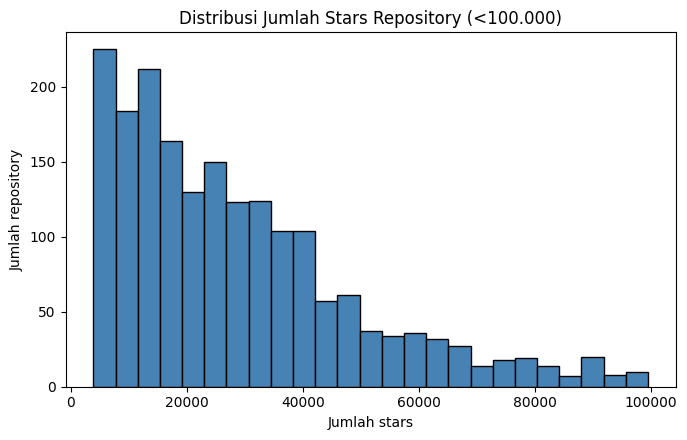

In [18]:
plt.figure(figsize=(7, 4.5))
plt.hist(df[df["stargazers_count"] < 100000]["stargazers_count"], bins=25,
         color="steelblue", edgecolor="black")
plt.title("Distribusi Jumlah Stars Repository (<100.000)")
plt.xlabel("Jumlah stars")
plt.ylabel("Jumlah repository")
plt.tight_layout()
plt.savefig("charts/1_histogram_stars.png")
plt.show()

Kebanyakan repository stars-nya di kisaran rendah (belasan ribu), dan
semakin besar jumlah stars, jumlah repo-nya semakin sedikit.

**2. Bar chart - jumlah repo per bahasa pemrograman (kategorikal)**

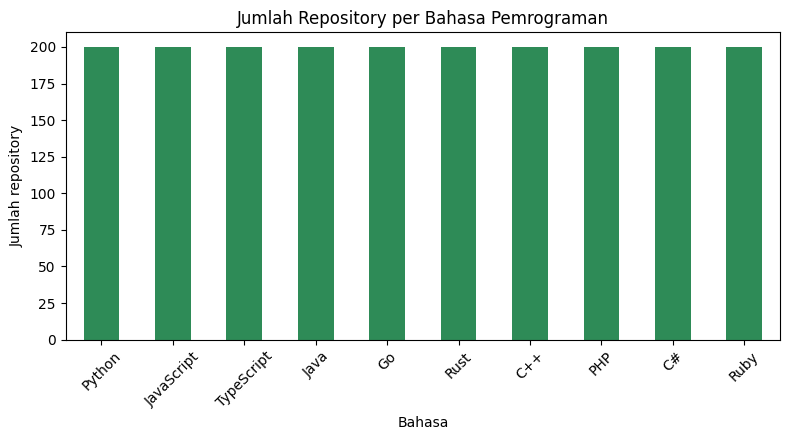

In [19]:
plt.figure(figsize=(8, 4.5))
df["language"].value_counts().plot(kind="bar", color="seagreen")
plt.title("Jumlah Repository per Bahasa Pemrograman")
plt.xlabel("Bahasa")
plt.ylabel("Jumlah repository")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/2_barchart_language.png")
plt.show()

Semua sama rata 200 karena memang begitu cara saya mengambil datanya,
jadi grafik ini lebih untuk menunjukkan kalau data yang saya kumpulkan
seimbang antar bahasa.

**3. Scatter plot - hubungan stars dan forks**

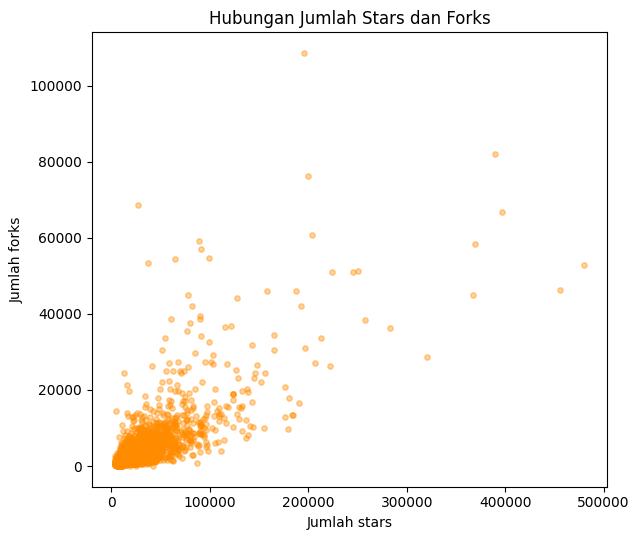

In [20]:
plt.figure(figsize=(6.5, 5.5))
plt.scatter(df["stargazers_count"], df["forks_count"], alpha=0.4, s=15, color="darkorange")
plt.title("Hubungan Jumlah Stars dan Forks")
plt.xlabel("Jumlah stars")
plt.ylabel("Jumlah forks")
plt.tight_layout()
plt.savefig("charts/3_scatter_stars_forks.png")
plt.show()

Titik-titiknya cenderung naik dari kiri bawah ke kanan atas, artinya
repo yang bintangnya banyak biasanya juga di-fork lebih banyak orang.

**4. Correlation heatmap - antar kolom numerik**

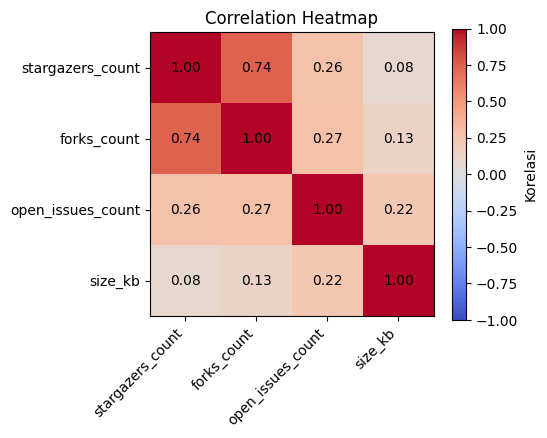

In [21]:
kolom_numerik = ["stargazers_count", "forks_count", "open_issues_count", "size_kb"]
corr = df[kolom_numerik].corr()

plt.figure(figsize=(5.5, 4.5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Korelasi")
plt.xticks(range(len(kolom_numerik)), kolom_numerik, rotation=45, ha="right")
plt.yticks(range(len(kolom_numerik)), kolom_numerik)
# tulis angkanya di tiap kotak biar gampang dibaca
for i in range(len(kolom_numerik)):
    for j in range(len(kolom_numerik)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("charts/4_correlation_heatmap.png")
plt.show()

Korelasi stars dengan forks cukup tinggi yaitu 0,74. Sedangkan size_kb
(ukuran repo) korelasinya kecil sekali dengan stars (0,07), jadi ukuran repo
ternyata tidak terlalu berhubungan dengan seberapa populer repo tersebut.

**5. Boxplot - jumlah stars per bahasa (dibatasi <100.000 juga)**

<Figure size 900x500 with 0 Axes>

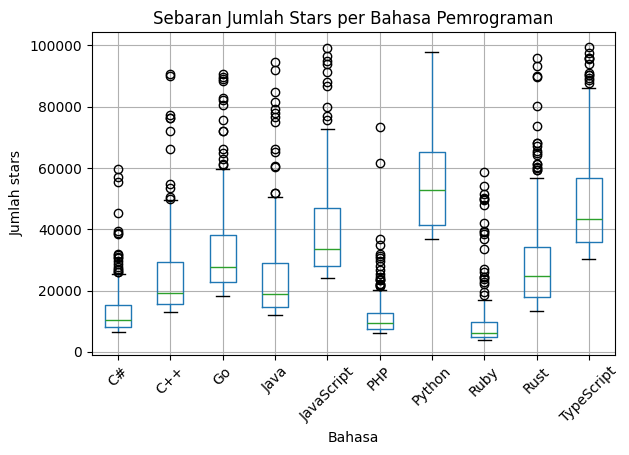

In [22]:
plt.figure(figsize=(9, 5))
data_boxplot = df[df["stargazers_count"] < 100000]
data_boxplot.boxplot(column="stargazers_count", by="language", rot=45)
plt.title("Sebaran Jumlah Stars per Bahasa Pemrograman")
plt.suptitle("")  # hilangkan judul otomatis dari pandas
plt.xlabel("Bahasa")
plt.ylabel("Jumlah stars")
plt.tight_layout()
plt.savefig("charts/5_boxplot_stars_language.png")
plt.show()

Terlihat Python, TypeScript, dan JavaScript median-nya lebih tinggi
dibanding bahasa lain seperti PHP atau Ruby. Tiap bahasa juga masih ada
beberapa titik di luar kotak (outlier) yang menunjukkan ada repo-repo
tertentu yang jauh lebih populer dibanding repo lain di bahasa yang sama.